In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import time
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

from src.preprocessing import read_image, windy_preprocessing_pipeline
from tqdm import tqdm
from datetime import datetime

sys.path


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



['/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python311.zip',
 '/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11',
 '/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload',
 '',
 '/Users/trantrunghcmut/Documents/hcmut/Undergraduation Thesis - Thunderstorm Nowcasting/Thunderstorm-Nowcasting-Geometry-Approach/.venv/lib/python3.11/site-packages',
 '/Users/trantrunghcmut/Documents/hcmut/Undergraduation Thesis - Thunderstorm Nowcasting/Thunderstorm-Nowcasting-Geometry-Approach']

In [34]:
DATASET = "KGRR"
# DATASET = "KDVN"
# DATASET = "KARX"

MODEL_NAME = "etitan"

MAX_VELOCITY = 500.0  # in pixels per time unit

### Load data first

In [35]:
from src.preprocessing import read_numpy_grid, nexrad_numpy_preprocessing_pipeline
from tqdm import tqdm

SOURCE_PATH = f"data/numpy_grid/{DATASET}"

img_paths = [
    os.path.join(SOURCE_PATH, img_name) for img_name in sorted(os.listdir(SOURCE_PATH)) if img_name.endswith('.npy')
]

img_shape = read_numpy_grid(img_paths[0]).shape       # get shape of the image

print(f"Image shape: {img_shape}")
print(f"-" * 20)

time_frames = []
dbz_maps = []

for path in tqdm(img_paths, desc="Processing images and detecting storms"):
    file_name = path.split("/")[-1].split(".")[0]
    # time_frames.append(datetime.strptime(file_name[:-4], '%Y%m%d-%H%M%S'))       # Get file name without extension
    time_frames.append(datetime.strptime(file_name[4:19], "%Y%m%d_%H%M%S"))       # Get file name without extension
    img = read_numpy_grid(path)
    dbz_maps.append(nexrad_numpy_preprocessing_pipeline(img))

FIRST_TIME_FRAME = time_frames[0]

print(f"Number of frames: {len(dbz_maps)}")

Image shape: (901, 901)
--------------------


Processing images and detecting storms: 100%|██████████| 31/31 [00:00<00:00, 277.84it/s]

Number of frames: 31


## Load model

In [36]:
from src.models import ETitanPrecipitationModel
from src.identification import HypothesisIdentifier, MorphContourIdentifier
from src.cores.base import StormsMap
from src.preprocessing import convert_polygons_to_contours

model = ETitanPrecipitationModel(identifier=MorphContourIdentifier())

storms_maps: list[StormsMap] = []
total_storms = 0

pbar = tqdm(zip(dbz_maps, time_frames), total=len(dbz_maps), desc="Detecting storms")
for idx, (dbz_map, time_frame) in enumerate(pbar):
    storms_map = model.identify_storms(dbz_map, time_frame, map_id=f"time_{idx}", threshold=35, filter_area=50)
    total_storms += len(storms_map.storms)
    pbar.set_postfix({"Total storms detected": total_storms})

    storms_maps.append(storms_map)

Detecting storms: 100%|██████████| 31/31 [00:34<00:00,  1.11s/it, Total storms detected=817]


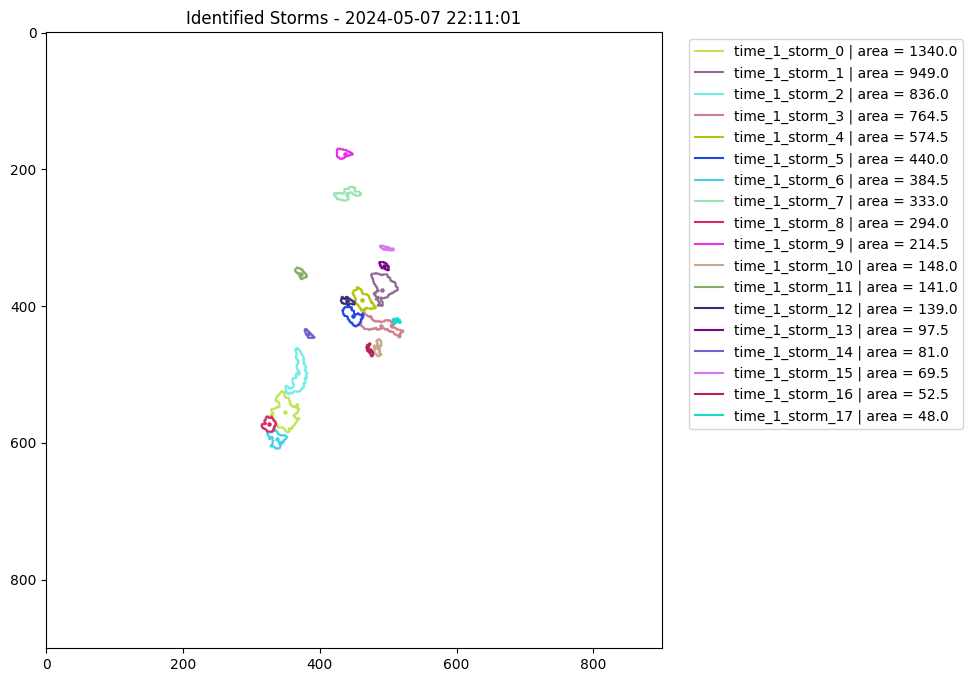

In [37]:
# Visualize storms with contours on the first DBZ map
storms_map = storms_maps[1]
plt.figure(figsize=(10, 8))

img_shape = dbz_maps[0].shape
img_shape = (img_shape[0], img_shape[1], 3)
blank_image = np.ones(img_shape, dtype=np.uint8) * 255

# colors = spectral_colors(len(storms_map.storms))

for storm in storms_map.storms:
    y_centroid, x_centroid = storm.centroid
    color = storm.contour_color
    
    plt.plot([], [], color=np.array(color)/255.0, label=f"{storm.id} | area = {storm.contour.area:.1f}")
    plt.scatter(x_centroid, y_centroid, color=np.array(color)/255.0, s=5)
    cv2.drawContours(blank_image, convert_polygons_to_contours([storm.contour]), -1, color, thickness=2)  # Draw contour in red

plt.imshow(blank_image, cmap='grey')
plt.title(f"Identified Storms - {storms_map.time_frame}")
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1.0))

plt.show()

In [38]:
import pandas as pd
import numpy as np
import os

SAVED_PATH = "output/tracking/nowcasting_evaluation.csv"

if os.path.exists(SAVED_PATH):
    df = pd.read_csv(SAVED_PATH)
else:
    df = pd.DataFrame(columns=["Dataset", "Model", "pod", "far", "csi"])

df

,Dataset,Model,pod,far,csi
0,KARX_3,ata,0.323506,0.674884,0.194722
1,KARX_3,etitan,0.445524,0.580177,0.278975
2,KARX_3,iscit,0.320916,0.697903,0.185214
3,KARX_3,ours,0.515200,0.507900,0.336600
4,KARX_3,stitan,0.377633,0.634568,0.232655
5,KARX_3,titan,0.390200,0.634700,0.237700
6,KARX_3,titan,0.389700,0.632749,0.238874
7,KARX_5,ata,0.190251,0.803163,0.106187
8,KARX_5,etitan,0.319585,0.711714,0.177955
9,KARX_5,iscit,0.240302,0.780431,0.127124


In [39]:
from src.cores.base import StormsMap
from src.cores.metrics import pod_score, far_score, csi_score
from src.models import ETitanPrecipitationModel

class PredictionBenchmarkModel:
    def __init__(self):
        self.pods = []
        self.fars = []
        self.csis = []
        self.actual = []
        self.predicted = []

    def evaluate_predict(self, actual_storms_map: StormsMap, predicted_storms_map: StormsMap):
        self.actual.append(actual_storms_map)
        self.predicted.append(predicted_storms_map)
        self.pods.append(pod_score(actual_storms_map, predicted_storms_map))
        self.fars.append(far_score(actual_storms_map, predicted_storms_map))
        self.csis.append(csi_score(actual_storms_map, predicted_storms_map))

# Create benchmark model
benchmark_model = PredictionBenchmarkModel()
PREDICT_FORWARD_STEPS = 3
SLOW_START_STEPS = 3

model = ETitanPrecipitationModel(identifier=MorphContourIdentifier())  # max_velocity in pixels per hour
temp_storm_map = storms_maps

ours_model_evaluation = PredictionBenchmarkModel()
predicted_maps = []
lead_times = []

for i in range(SLOW_START_STEPS):
    model.processing_map(temp_storm_map[i])  # Warm-up phase

for curr_map, future_map in tqdm(list(zip(temp_storm_map[SLOW_START_STEPS:], temp_storm_map[PREDICT_FORWARD_STEPS + SLOW_START_STEPS:])), desc="Predicting precipitation maps"):
    # Predict map using current data
    dt_seconds = (future_map.time_frame - model.storms_maps[-1].time_frame).total_seconds()
    predicted_map = model.forecast(dt_seconds)
    ours_model_evaluation.evaluate_predict(future_map, predicted_map)
    lead_times.append(dt_seconds)

    # Update new map into knowledge
    model.processing_map(curr_map)  # Update model with the current map

print("Our model evaluation:")
print(f"\tAverage POD: {np.mean(ours_model_evaluation.pods):.4f}")
print(f"\tAverage FAR: {np.mean(ours_model_evaluation.fars):.4f}")
print(f"\tAverage CSI: {np.mean(ours_model_evaluation.csis):.4f}")

new_row = {
    "Dataset": f"{DATASET}_3",
    "Model": MODEL_NAME,
    "pod": np.mean(ours_model_evaluation.pods),
    "far": np.mean(ours_model_evaluation.fars),
    "csi": np.mean(ours_model_evaluation.csis)
}

# Check if the entry already exists
existing_entry = df[(df["Dataset"] == f"{DATASET}_3") & (df["Model"] == MODEL_NAME)]
if not existing_entry.empty:
    df.update(pd.DataFrame([new_row], index=existing_entry.index))
else:
    df.loc[len(df)] = new_row

df.sort_values(by=["Dataset", "Model"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.to_csv(SAVED_PATH, index=False)

print(f"\tAverage lead time: {np.mean(lead_times) / 60:.2f} minutes")

Predicting precipitation maps: 100%|██████████| 25/25 [00:04<00:00,  5.54it/s]

Our model evaluation:
	Average POD: 0.3405
	Average FAR: 0.6098
	Average CSI: 0.2230
	Average lead time: 23.10 minutes


In [40]:
benchmark_model = PredictionBenchmarkModel()
PREDICT_FORWARD_STEPS = 5
SLOW_START_STEPS = 5

model = ETitanPrecipitationModel(identifier=HypothesisIdentifier())  # max_velocity in pixels per hour
temp_storm_map = storms_maps

ours_model_evaluation = PredictionBenchmarkModel()
predicted_maps = []
lead_times = []

for i in range(SLOW_START_STEPS):
    model.processing_map(temp_storm_map[i])  # Warm-up phase

for curr_map, future_map in tqdm(list(zip(temp_storm_map[SLOW_START_STEPS:], temp_storm_map[PREDICT_FORWARD_STEPS + SLOW_START_STEPS:])), desc="Predicting precipitation maps"):
    # Predict map using current data
    dt_seconds = (future_map.time_frame - model.storms_maps[-1].time_frame).total_seconds()
    predicted_map = model.forecast(dt_seconds)
    ours_model_evaluation.evaluate_predict(future_map, predicted_map)
    lead_times.append(dt_seconds)

    # Update new map into knowledge
    model.processing_map(curr_map)  # Update model with the current map

print("Our model evaluation:")
print(f"\tAverage POD: {np.mean(ours_model_evaluation.pods):.4f}")
print(f"\tAverage FAR: {np.mean(ours_model_evaluation.fars):.4f}")
print(f"\tAverage CSI: {np.mean(ours_model_evaluation.csis):.4f}")

new_row = {
    "Dataset": f"{DATASET}_5",
    "Model": MODEL_NAME,
    "pod": np.mean(ours_model_evaluation.pods),
    "far": np.mean(ours_model_evaluation.fars),
    "csi": np.mean(ours_model_evaluation.csis)
}

# Check if the entry already exists
existing_entry = df[(df["Dataset"] == f"{DATASET}_5") & (df["Model"] == MODEL_NAME)]
if not existing_entry.empty:
    df.update(pd.DataFrame([new_row], index=existing_entry.index))
else:
    df.loc[len(df)] = new_row

df.sort_values(by=["Dataset", "Model"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.to_csv(SAVED_PATH, index=False)

# raise Exception("Stop here")

Predicting precipitation maps: 100%|██████████| 21/21 [00:03<00:00,  5.44it/s]

Our model evaluation:
	Average POD: 0.2248
	Average FAR: 0.7198
	Average CSI: 0.1428


# Overall Analyzing on tracking process
In this tracking, I used both of the median duration and linearity error of tracking

Average object consistency score (area change rate): 0.2152


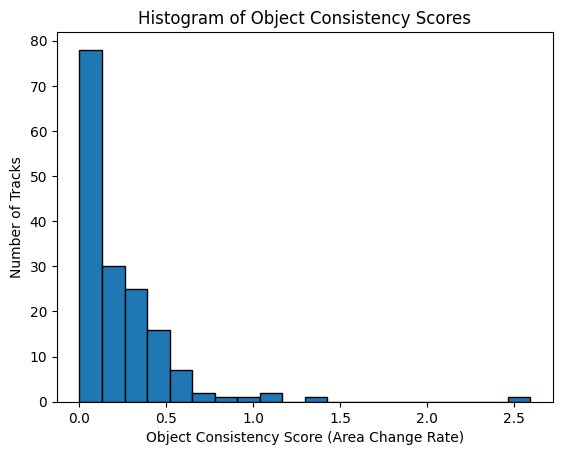

In [41]:
object_consistency_scores = []

for track in model.tracker.tracks:
    areas = [storm.contour.area for storm in track.storms.values()]
    area_changes = [abs(areas[i] - areas[i - 1]) / areas[i - 1] for i in range(1, len(areas)) if areas[i - 1] != 0]
    object_consistency_scores.append(np.mean(area_changes) if area_changes else 0)

object_consistency_scores = np.array(object_consistency_scores)

print(f"Average object consistency score (area change rate): {np.mean(object_consistency_scores):.4f}")

plt.hist(object_consistency_scores, bins=20, edgecolor='black')
plt.title("Histogram of Object Consistency Scores")
plt.xlabel("Object Consistency Score (Area Change Rate)")
plt.ylabel("Number of Tracks")
plt.show()

## B. Mean duration tracking

Median duration of tracking: 4.317073170731708 frames
Maximum duration of tracking: 21 frames
Mean duration of tracking: 4.32 frames


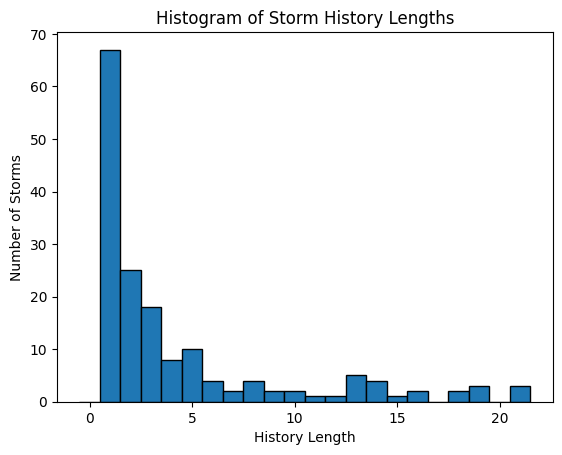

In [42]:
HISTORY_LENGTH_LST = []             # Retrieve history length of all storms

for track in model.tracker.tracks:
    HISTORY_LENGTH_LST.append(len(track.storms))   # Append history length of each storm track

MEAN_DURATION = np.mean(HISTORY_LENGTH_LST)

print(f"Median duration of tracking: {MEAN_DURATION} frames")
print(f"Maximum duration of tracking: {max(HISTORY_LENGTH_LST)} frames")
print(f"Mean duration of tracking: {np.mean(HISTORY_LENGTH_LST):.2f} frames")

plt.hist(HISTORY_LENGTH_LST, bins=range(0, max(HISTORY_LENGTH_LST) + 2), align='left', edgecolor='black')
plt.title("Histogram of Storm History Lengths")
plt.xlabel("History Length")
plt.ylabel("Number of Storms")
plt.show()

## C. Linearity error tracking
Use linearity to track the different between linear fitting of previous history against the actual matched movement

In [43]:
from src.cores.metrics import linear_tracking_error
import matplotlib.pyplot as plt

# Accumulate linear errors for all storms
LINEAR_ERRORS_LST = []

for storms_map in tqdm(storms_maps, desc="Computing linear fitting errors for storms"):
    for storm in storms_map.storms:
        # If not enough history, skip
        if len(storm.history_movements) <= MEAN_DURATION:
            continue

        # Fit linear model
        error_distance = linear_tracking_error(storm.history_movements[:-1]) ** 2      # Final one used for evaluate the movement prediction
        LINEAR_ERRORS_LST.append(error_distance)

print(f"RMSE of linear fitting errors: {np.sqrt(np.mean(LINEAR_ERRORS_LST)):.4f}. Total length: {len(LINEAR_ERRORS_LST)}")

Computing linear fitting errors for storms: 100%|██████████| 31/31 [00:00<00:00, 428.80it/s]

RMSE of linear fitting errors: 23.5307. Total length: 337


In [44]:
import colorsys

def spectral_colors(n: int) -> list[list[int]]:
    colors = []
    for i in range(n):
        # Hue ranges from 0.0 (red) to 0.83 (violet) approximately
        hue = i / max(1, n - 1) * 0.83  
        r, g, b = colorsys.hsv_to_rgb(hue, 1.0, 1.0)
        colors.append([int(r * 255), int(g * 255), int(b * 255)])
    return colors

Processing all storm maps for movement history visualization: 100%|██████████| 31/31 [00:04<00:00,  6.53it/s]


----  CURRENT MAP at time 2024-05-08 00:57:09  ----
Storm 0: Number of movement history records: 9
Storm 1: Number of movement history records: 18
Storm 2: Number of movement history records: 10
Storm 3: Number of movement history records: 17
Storm 4: Number of movement history records: 9
Storm 5: Number of movement history records: 2
Storm 6: Number of movement history records: 10
Storm 7: Number of movement history records: 7
Storm 8: Number of movement history records: 25
Storm 9: Number of movement history records: 0
Storm 10: Number of movement history records: 2
Storm 11: Number of movement history records: 5
Storm 12: Number of movement history records: 3
Storm 13: Number of movement history records: 7
Storm 14: Number of movement history records: 17
Storm 15: Number of movement history records: 8
Storm 16: Number of movement history records: 0
Storm 17: Number of movement history records: 1


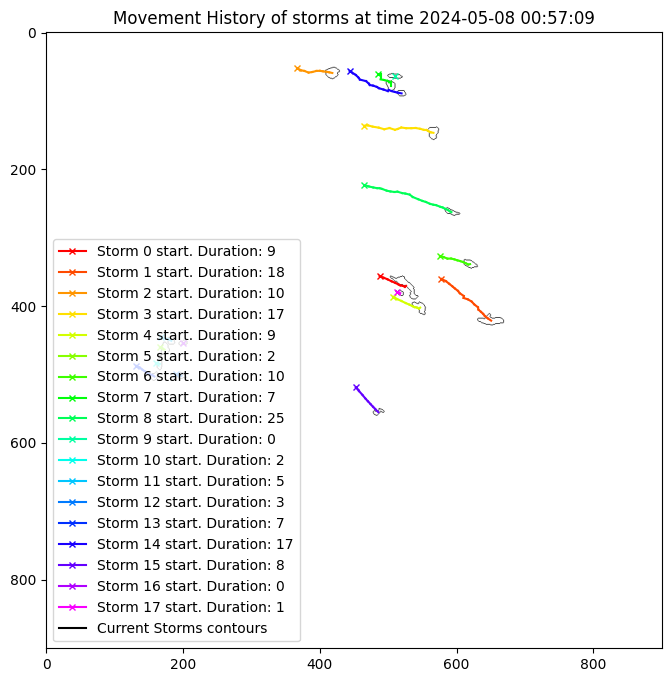

In [45]:
from src.preprocessing import convert_polygons_to_contours

num_maps = len(storms_maps)

model = ETitanPrecipitationModel(identifier=HypothesisIdentifier())  # max_velocity in pixels per hour

for i in tqdm(range(num_maps), desc="Processing all storm maps for movement history visualization"):
    model.processing_map(storms_maps[i])  # Warm-up phase

plt.figure(figsize=(8, 8))
blank_img = np.ones(shape=(img_shape[0], img_shape[1], 3), dtype=np.uint8) * 255

current_map = storms_maps[-1]
print(f"----  CURRENT MAP at time {current_map.time_frame.strftime('%Y-%m-%d %H:%M:%S')}  ----")

colors = spectral_colors(len(current_map.storms))

for idx, storm in enumerate(current_map.storms):
    print(f"Storm {idx}: Number of movement history records: {len(storm.history_movements)}")
    current_frame = current_map.time_frame

    color = np.array(colors[idx]) / 255.0
    end_point = (storm.contour.centroid.x, storm.contour.centroid.y)

    # backtrack the movement history
    for move_idx, movement in enumerate(storm.history_movements):
        prev_frame = storms_maps[-(move_idx + 2)].time_frame
        dt = (current_frame - prev_frame).seconds / 3600
        current_frame = prev_frame

        dy, dx = movement[0] * dt, movement[1] * dt

        start = end_point[0] - dx, end_point[1] - dy
        plt.plot([start[0], end_point[0]], [start[1], end_point[1]], color=color)
        end_point = start
    
    plt.plot(end_point[0], end_point[1], marker='x', color=color, markersize=5, label=f'Storm {idx} start. Duration: {len(storm.history_movements)}')

contours = convert_polygons_to_contours([storm.contour for storm in current_map.storms])
cv2.drawContours(blank_img, contours, -1, (0, 0, 0), 1)
plt.plot([], [], color='black', label='Current Storms contours')
plt.title(f"Movement History of storms at time {current_map.time_frame.strftime('%Y-%m-%d %H:%M:%S')}")

plt.imshow(blank_img)
plt.legend()

plt.show()

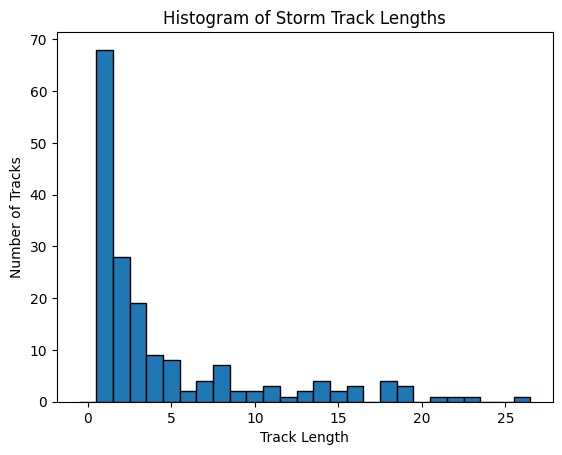

In [46]:
# Get the centroids list
centroids = []
clusters_assigned = []

def _convert_time_frame_to_seconds(time_frame: datetime) -> float:
    return time_frame.timestamp() - FIRST_TIME_FRAME.timestamp()

for track_history in model.tracker.tracks:
    track_centroids = [(storm.centroid[0], storm.centroid[1], _convert_time_frame_to_seconds(time_frame)) for time_frame, storm in track_history.storms.items()]
    centroids.extend(track_centroids)
    clusters_assigned.extend([track_history.id] * len(track_centroids))

centroids = np.array(centroids)

track_lengths = [len(track_history.storms) for track_history in model.tracker.tracks]

plt.hist(track_lengths, bins=range(0, max(track_lengths) + 2), align='left', edgecolor='black')
plt.title("Histogram of Storm Track Lengths")
plt.xlabel("Track Length")
plt.ylabel("Number of Tracks")
plt.show()

In [47]:
from typing import Annotated
from src.cores.metrics.postevent_tracking import PostEventClustering
    
postevent_analysis = PostEventClustering(centroids, max_window_time=600, spatial_distance_threshold=50)
reassigned_clusters_centers = postevent_analysis.fit_transform(num_clusters=len(model.tracker.tracks), clusters_assigned=clusters_assigned, max_epochs=50)

active_lst = [i for i, cluster in enumerate(postevent_analysis.clusters) if cluster.is_actived]
print(f"Total {len(active_lst)} / {postevent_analysis.num_initial_clusters} Clusters active: {active_lst}")
print(f"Number of active storm tracks after post-event clustering: {len([c for c in reassigned_clusters_centers if c != -1])} / {len(reassigned_clusters_centers)}")

# Scoring: 1 if match best clusters, 0.5 if match wrong clusters and 0 if storm is dropped
merged_clusters_assigned = [postevent_analysis.clusters_merged_dict.get(i, i) for i in clusters_assigned]
score_lst = [1 if merged_clusters_assigned[i] == reassigned_clusters_centers[i] else 0.5 if reassigned_clusters_centers[i] != -1 else 0 for i in range(len(clusters_assigned))]
print(f"Post-event clustering scoring results: {sum(score_lst) / len(score_lst):.4f}")

Post-event clustering:   0%|          | 0/50 [00:00<?, ?it/s]

Total 88 / 175 Clusters active: [0, 1, 2, 3, 4, 6, 7, 10, 11, 13, 14, 15, 18, 22, 24, 25, 28, 29, 32, 42, 44, 45, 47, 49, 51, 53, 54, 57, 59, 65, 66, 68, 70, 71, 72, 73, 75, 76, 77, 80, 82, 84, 88, 90, 91, 92, 93, 96, 99, 101, 103, 108, 110, 111, 112, 114, 116, 117, 122, 123, 124, 127, 128, 132, 135, 136, 137, 138, 140, 141, 143, 145, 146, 147, 150, 154, 156, 157, 158, 160, 161, 162, 163, 164, 166, 168, 169, 170]
Number of active storm tracks after post-event clustering: 795 / 817
Post-event clustering scoring results: 0.8415


In [48]:
import pandas as pd
import numpy as np
import os

SAVED_PATH = "output/tracking/tracking_evaluation_results.csv"

if os.path.exists(SAVED_PATH):
    df = pd.read_csv(SAVED_PATH)
else:
    df = pd.DataFrame(columns=["Dataset", "Model", "object_consistency", "mean_duration", "linear_rmse", "postevent_score"])

new_row = {
    "Dataset": DATASET,
    "Model": MODEL_NAME,
    "object_consistency": np.mean(object_consistency_scores),
    "mean_duration": np.mean(MEAN_DURATION),
    "linear_rmse": np.sqrt(np.mean(LINEAR_ERRORS_LST)),
    "postevent_score": sum(score_lst) / len(score_lst)
}

# Check if the entry already exists
existing_entry = df[(df["Dataset"] == DATASET) & (df["Model"] == MODEL_NAME)]
if not existing_entry.empty:
    df.update(pd.DataFrame([new_row], index=existing_entry.index))
else:
    df.loc[len(df)] = new_row

df.sort_values(by=["Dataset", "Model"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.to_csv(SAVED_PATH, index=False)
df

,Dataset,Model,object_consistency,mean_duration,linear_rmse,postevent_score
0,KARX,ata,4.287997,7.975628,22.020196,0.930312
1,KARX,etitan,0.225845,5.248062,53.923449,0.691285
2,KARX,iscit,0.173936,13.997784,116.194840,0.011448
3,KARX,ours,0.220307,5.384615,99.568784,0.884417
4,KARX,stitan,3.475859,5.247145,68.419759,0.542822
5,KARX,titan,5.035517,18.210487,255.576655,0.759601
6,KDVN,ata,0.407580,7.412000,44.233640,0.752183
7,KDVN,etitan,0.395278,4.361905,63.128128,0.752000
8,KDVN,iscit,0.092951,31.056000,116.416769,0.511000
9,KDVN,ours,0.218634,4.523810,68.320747,0.754000
